# 🌊 OceanoIA — Módulo 1: CNN para Identificación de Especies Marinas
En este apartado se encuentra el flujo completo que se implementó para el desarrollo de la red neuronal convolucional (CNN) en la cual se clasifican especies marinas capturadas en los mares de Costa Rica.

In [1]:
# Librerias
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')
print("TensorFlow versión:", tf.__version__)

TensorFlow versión: 2.21.0


## 3. Preprocesamiento y División de Datos
En este apartadose hizo la división del dataset raw (las imágenes en crudo) en 80% para entrenamiento y el 20% para pruebas

In [2]:
# El script 'src/data_prep.py' realiza esta división de manera balanceada (800 train, 200 test por clase)
# Mapeos aplicados:
# - Gilt-Head Bream -> dorado
# - Hourse Mackerel -> atun_aleta_amarilla
# - Red Sea Bream -> pargo_mancha
# - Sea Bass -> corvina_reina
# - Trout -> marlin_pez_vela (Especie protegida)
# - Shrimp -> tortuga_marina (Especie protegida)
# - Black Sea Sprat -> tiburon_martillo (Especie en veda)
# - Red Mullet + Striped Red Mullet -> otros

print("Para iniciar la partición, ejecuta en terminal: python src/data_prep.py")

Para iniciar la partición, ejecuta en terminal: python src/data_prep.py


In [3]:
## 4. Aumento de Datos y Generadores de Keras
train_path = '../data/processed/train'
test_path = '../data/processed/test'
image_shape = (128, 128, 3)
batch_size = 32

# Definición de transformaciones para el conjunto de entrenamiento
image_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    rescale=1/255,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Para pruebas solo escalamos los píxeles
test_gen_base = ImageDataGenerator(rescale=1/255)

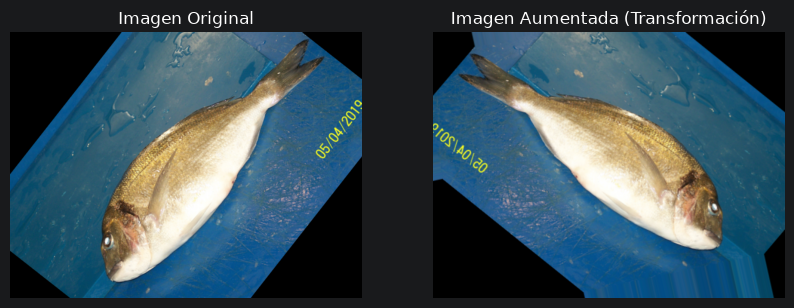

In [4]:
# Visualizar un ejemplo de transformación
sample_img_path = os.path.join(train_path, 'dorado', os.listdir(os.path.join(train_path, 'dorado'))[0])
sample_img = imread(sample_img_path)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_gen.random_transform(sample_img))
plt.title('Imagen Aumentada (Transformación)')
plt.axis('off')

plt.show()

In [5]:
# Generadores de flujo
train_image_generator = image_gen.flow_from_directory(
    train_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

test_image_generator = test_gen_base.flow_from_directory(
    test_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 6400 images belonging to 8 classes.
Found 1600 images belonging to 8 classes.


## 5. Diseño de la Arquitectura CNN

Implementamos la estructura sugerida en el diseño del proyecto para clasificación multiclase.

In [6]:
model = Sequential()

# Bloque 1: Conv2D(32) -> MaxPooling
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=image_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque 2: Conv2D(64) -> MaxPooling
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque 3: Conv2D(128) -> MaxPooling
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanado
model.add(Flatten())

# Capa Densa (256 Neuronas)
model.add(Dense(256, activation='relu'))

# Dropout para regularización
model.add(Dropout(0.5))

# Capa de Salida Softmax (8 clases)
model.add(Dense(8, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,088 (24.86 MB)

 Trainable params: 6,518,088 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento del Modelo

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [8]:
 # Entrenamiento
results = model.fit(
    train_image_generator,
    epochs=20,
    validation_data=test_image_generator,
    callbacks=[early_stop]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.3345 - loss: 1.6631 - val_accuracy: 0.4544 - val_loss: 1.6036
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.5736 - loss: 1.0772 - val_accuracy: 0.5337 - val_loss: 1.7626
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 196s 978ms/step - accuracy: 0.6758 - loss: 0.8318 - val_accuracy: 0.6150 - val_loss: 1.4378
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.7600 - loss: 0.6424 - val_accuracy: 0.7038 - val_loss: 1.2400
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.8098 - loss: 0.5242 - val_accuracy: 0.6719 - val_loss: 1.3952
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 170s 852ms/step - accuracy: 0.8436 - loss: 0.4237 - val_accuracy: 0.6881 - val_loss: 1.1262
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 185s 927ms/step - accuracy: 0.8720 - loss: 0.3443 - val_accuracy: 0.7556 - val_loss: 1.0509
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.9036 - loss: 0.2670 -

In [9]:
# Guardar el modelo en formato Keras nativo
model.save('../models/cnn_especies.keras')

## 7. Evaluación del Modelo y Métricas

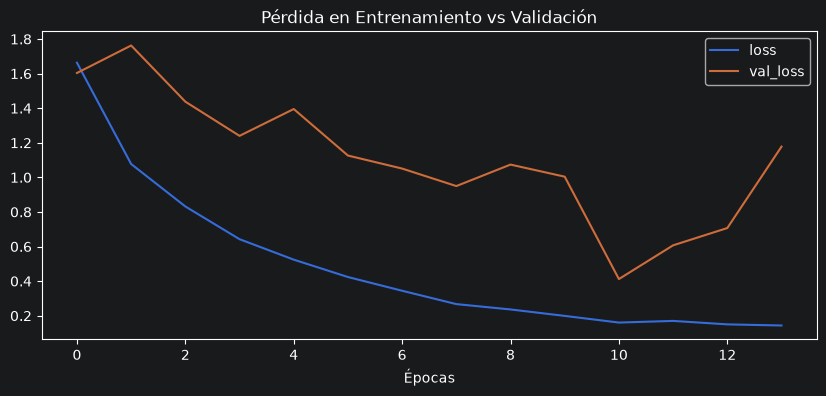

In [10]:
# Graficar pérdidas
losses = pd.DataFrame(model.history.history)
losses[['loss', 'val_loss']].plot(figsize=(10, 4))
plt.title('Pérdida en Entrenamiento vs Validación')
plt.xlabel('Épocas')
plt.show()

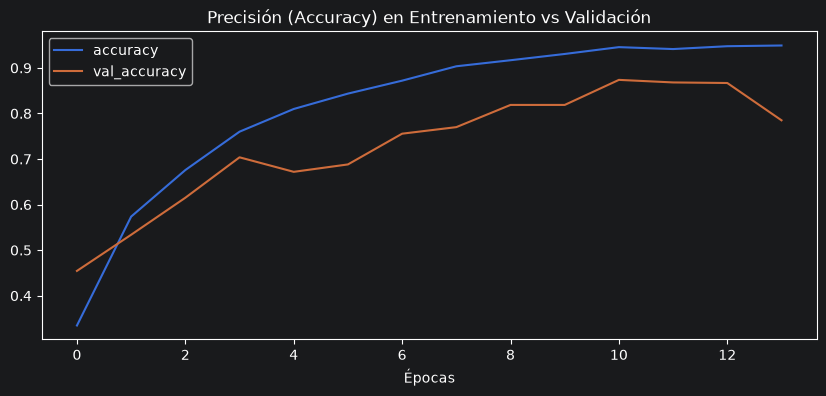

In [11]:
# Graficar precisión
losses[['accuracy', 'val_accuracy']].plot(figsize=(10, 4))
plt.title('Precisión (Accuracy) en Entrenamiento vs Validación')
plt.xlabel('Épocas')
plt.show()

In [12]:
# Evaluación cuantitativa
model.evaluate(test_image_generator)

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 267ms/step - accuracy: 0.8737 - loss: 0.4120


[0.4119551181793213, 0.8737499713897705]

In [13]:
# Reporte de Clasificación
preds = model.predict(test_image_generator)
predictions = np.argmax(preds, axis=-1)
true_classes = test_image_generator.classes
class_labels = list(test_image_generator.class_indices.keys())

print(classification_report(true_classes, predictions, target_names=class_labels))

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step
                     precision    recall  f1-score   support

atun_aleta_amarilla       0.99      0.76      0.86       200
      corvina_reina       0.79      0.84      0.82       200
             dorado       0.77      0.91      0.83       200
    marlin_pez_vela       0.88      1.00      0.94       200
              otros       0.96      0.72      0.82       200
       pargo_mancha       0.78      0.79      0.79       200
   tiburon_martillo       0.88      1.00      0.94       200
     tortuga_marina       1.00      0.97      0.98       200

           accuracy                           0.87      1600
          macro avg       0.88      0.87      0.87      1600
       weighted avg       0.88      0.87      0.87      1600



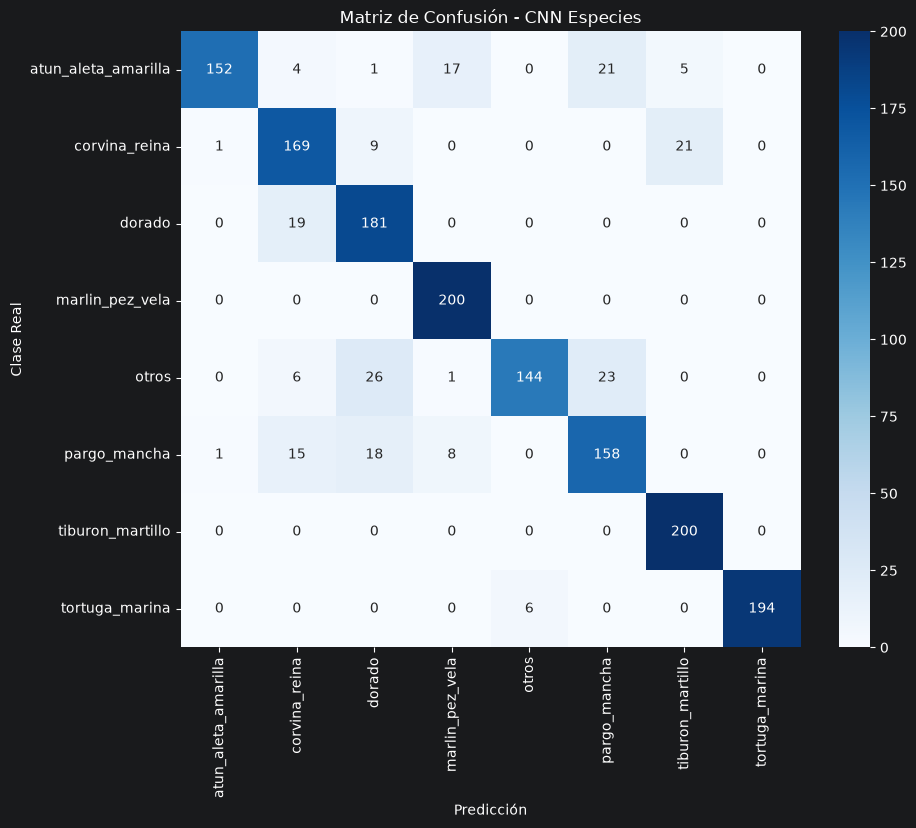

In [14]:
# Matriz de Confusión
cm = confusion_matrix(true_classes, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title('Matriz de Confusión - CNN Especies')
plt.ylabel('Clase Real')
plt.xlabel('Predicción')
plt.show()

## 8. Predicción sobre una Nueva Imagen

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


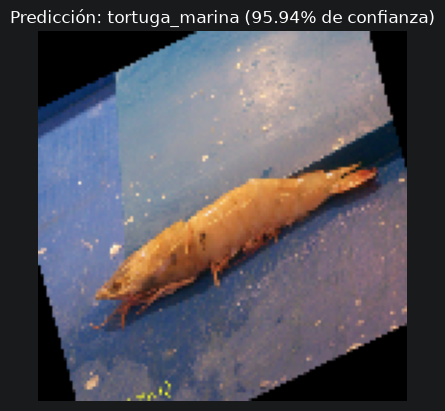

In [15]:
# Cargar una imagen aleatoria del test para validación
test_sub_dir = os.path.join(test_path, 'tortuga_marina')
test_img_name = os.listdir(test_sub_dir)[5]
ruta_nueva_imagen = os.path.join(test_sub_dir, test_img_name)

# Cargar y preprocesar para el modelo
nueva_imagen = image.load_img(ruta_nueva_imagen, target_size=image_shape[:2])
nueva_imagen_arr = image.img_to_array(nueva_imagen) / 255.0  # Normalización obligatoria
nueva_imagen_arr = np.expand_dims(nueva_imagen_arr, axis=0)

# Predicción
pred_probs = model.predict(nueva_imagen_arr)[0]
predicted_idx = np.argmax(pred_probs)
predicted_class = class_labels[predicted_idx]

plt.imshow(nueva_imagen)
plt.title(f"Predicción: {predicted_class} ({pred_probs[predicted_idx]*100:.2f}% de confianza)")
plt.axis('off')
plt.show()